# SHAP for the distilled listener

What each feature contributes to the GBT's score for a board word, on held-out
boards (gpt-oss teacher, 25% of board seeds never seen in training).

**Read these as scores, not probabilities.** The model is a conditional logit:
it emits one raw score per candidate word and a softmax *over the whole board*
turns those into probabilities. SHAP explains the raw score, which has no
meaning on its own -- only relative to the other words competing in the same
group. A +0.5 SHAP value means "this feature pushed this word half a logit
ahead of where it would otherwise have sat against its rivals".

Model: `cache/listener_gbt.txt` (177 trees, swept params).
Data: `cache/listener_val.npz`, precomputed so this notebook does not rebuild
features (~4 min).

In [1]:
%matplotlib inline
import numpy as np, lightgbm as lgb, shap, matplotlib.pyplot as plt

d = np.load("../cache/listener_val.npz", allow_pickle=False)
X, y, groups, step = d["X"], d["y"], d["groups"], d["step"]
names = [str(n) for n in d["names"]]
bst = lgb.Booster(model_file="../cache/listener_gbt.txt")

print(f"{X.shape[0]:,} rows x {X.shape[1]} features, {len(groups):,} choice events")
print(f"{bst.num_trees()} trees")

/home/maste/CodenamesAI/.venv/lib/python3.12/site-packages/numba/core/config.py:187: RuntimeWarning: Environment variable 'NUMBA_CUDA_USE_NVIDIA_BINDING' is defined but its associated value '1export' could not be parsed.
The parse failed with exception:
Traceback (most recent call last):
  File "/home/maste/CodenamesAI/.venv/lib/python3.12/site-packages/numba/core/config.py", line 185, in _readenv
    return ctor(value)
           ^^^^^^^^^^^
ValueError: invalid literal for int() with base 10: '1export'

  warnings.warn(f"Environment variable '{name}' is defined but "


224,506 rows x 32 features, 15,766 choice events
177 trees


/home/maste/CodenamesAI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Compute

Subsampled to 40k rows; SHAP on trees is exact, so this is purely about plot
density and runtime, not accuracy of the attributions.

In [2]:
rng = np.random.default_rng(0)
idx = rng.choice(len(X), size=min(40_000, len(X)), replace=False)
Xs = X[idx]

explainer = shap.TreeExplainer(bst)
sv = explainer.shap_values(Xs)
print("shap values:", sv.shape, " base value:", round(float(explainer.expected_value), 4))

shap values: (40000, 32)  base value: -0.6354


## Global importance — mean |SHAP|

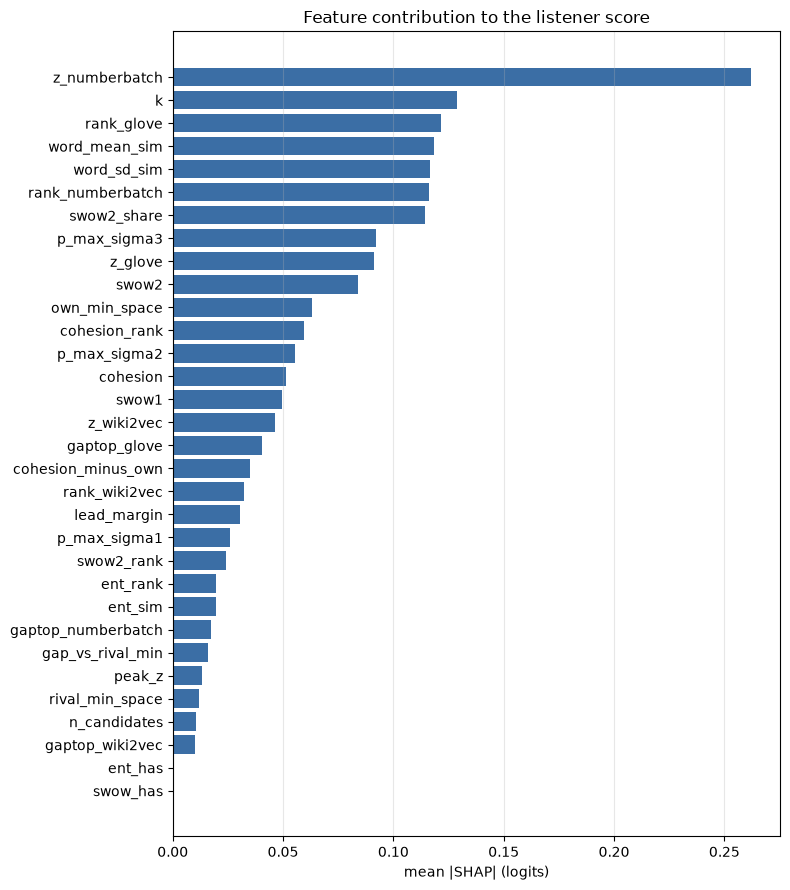

  z_numberbatch          0.2621
  k                      0.1287
  rank_glove             0.1218
  word_mean_sim          0.1184
  word_sd_sim            0.1165
  rank_numberbatch       0.1160
  swow2_share            0.1144
  p_max_sigma3           0.0921
  z_glove                0.0914
  swow2                  0.0838
  own_min_space          0.0630
  cohesion_rank          0.0593
  p_max_sigma2           0.0556
  cohesion               0.0514
  swow1                  0.0497
  z_wiki2vec             0.0464
  gaptop_glove           0.0404
  cohesion_minus_own     0.0351
  rank_wiki2vec          0.0324
  lead_margin            0.0303
  p_max_sigma1           0.0260
  swow2_rank             0.0241
  ent_rank               0.0196
  ent_sim                0.0195
  gaptop_numberbatch     0.0175
  gap_vs_rival_min       0.0161
  peak_z                 0.0131
  rival_min_space        0.0118
  n_candidates           0.0105
  gaptop_wiki2vec        0.0103
  ent_has                0.0007
  swow_h

In [3]:
mean_abs = np.abs(sv).mean(axis=0)
order = np.argsort(mean_abs)

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh([names[i] for i in order], mean_abs[order], color="#3b6ea5")
ax.set_xlabel("mean |SHAP| (logits)")
ax.set_title("Feature contribution to the listener score")
ax.grid(axis="x", alpha=.3)
plt.tight_layout(); plt.show()

for i in order[::-1]:
    print(f"  {names[i]:22s} {mean_abs[i]:.4f}")

## Beeswarm

Direction as well as magnitude: colour is the feature's own value, so a red
point on the right means "a high value of this feature pushed the score up".

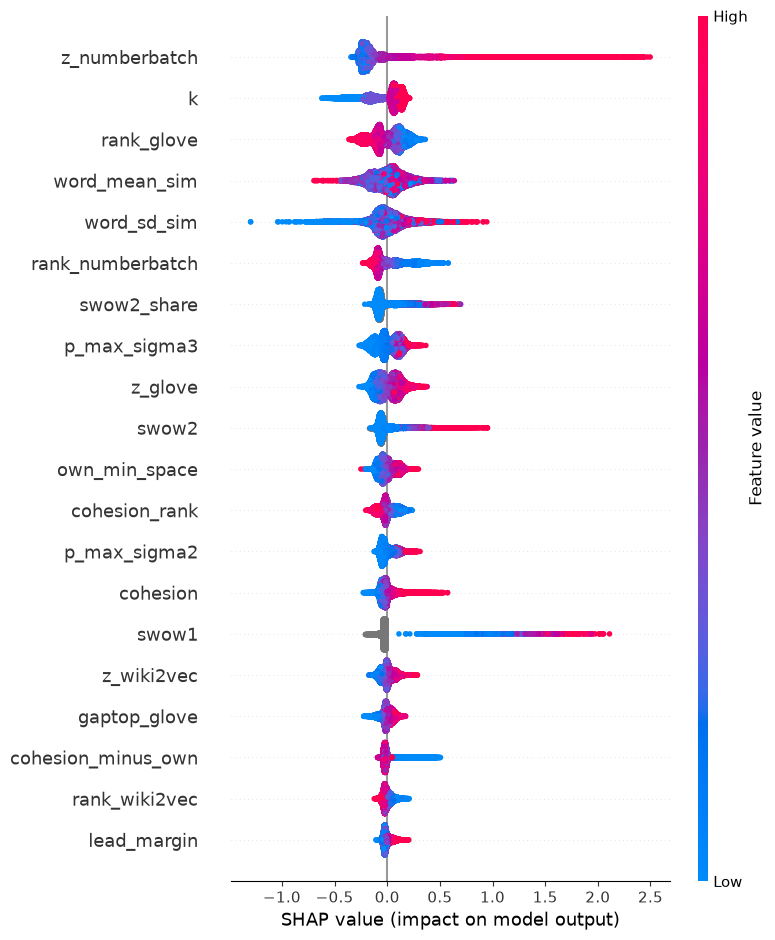

In [4]:
shap.summary_plot(sv, Xs, feature_names=names, max_display=20, show=False)
plt.tight_layout(); plt.show()

## By feature block

The ablation in `docs/log.md` measured blocks by retraining without them. SHAP
measures something different -- how much the fitted model *uses* each block --
and the two can disagree when features are redundant: a block can be heavily
used and still be ablation-null, because a dropped feature's information is
recoverable from its correlates.

  block              n  sum |SHAP|   share  per feature
  numberbatch        3      0.3956   21.1%       0.1319
  other spaces       6      0.3427   18.2%       0.0571
  SWOW               5      0.2720   14.5%       0.0544
  column stats       2      0.2349   12.5%       0.1174
  board context      4      0.1825    9.7%       0.0456
  analytic p_max     3      0.1737    9.2%       0.0579
  cohesion           3      0.1458    7.8%       0.0486
  multi-space        3      0.0910    4.8%       0.0303
  entity             3      0.0397    2.1%       0.0132


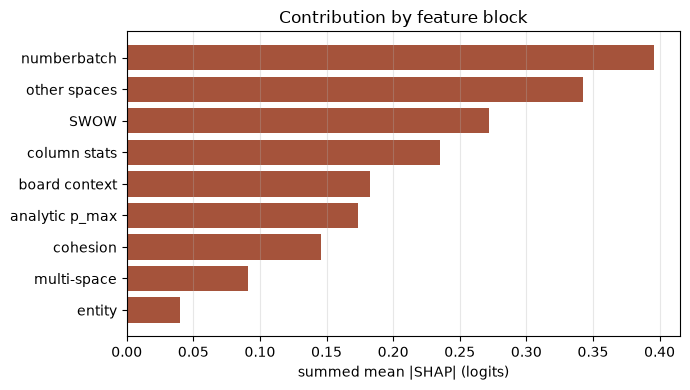

In [5]:
BLOCKS = {
    "numberbatch":   ["z_numberbatch", "rank_numberbatch", "gaptop_numberbatch"],
    "other spaces":  ["z_glove", "z_wiki2vec", "rank_glove", "rank_wiki2vec",
                      "gaptop_glove", "gaptop_wiki2vec"],
    "board context": ["k", "n_candidates", "peak_z", "lead_margin"],
    "analytic p_max":["p_max_sigma1", "p_max_sigma2", "p_max_sigma3"],
    "multi-space":   ["own_min_space", "rival_min_space", "gap_vs_rival_min"],
    "column stats":  ["word_mean_sim", "word_sd_sim"],
    "cohesion":      ["cohesion", "cohesion_rank", "cohesion_minus_own"],
    "SWOW":          ["swow1", "swow2", "swow2_rank", "swow2_share", "swow_has"],
    "entity":        ["ent_sim", "ent_rank", "ent_has"],
}
tot = mean_abs.sum()
rows = sorted(((b, sum(mean_abs[names.index(f)] for f in fs), len(fs))
               for b, fs in BLOCKS.items()), key=lambda r: -r[1])
print(f"  {'block':16s} {'n':>3s} {'sum |SHAP|':>11s} {'share':>7s} {'per feature':>12s}")
for b, v, n in rows:
    print(f"  {b:16s} {n:3d} {v:11.4f} {v/tot:7.1%} {v/n:12.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh([r[0] for r in rows][::-1], [r[1] for r in rows][::-1], color="#a5533b")
ax.set_xlabel("summed mean |SHAP| (logits)"); ax.grid(axis="x", alpha=.3)
ax.set_title("Contribution by feature block")
plt.tight_layout(); plt.show()

## SHAP vs LightGBM's own gain importance

Gain counts how much each split improved the objective, which rewards features
used early and often on large nodes. They should broadly agree; where they do
not, gain is usually the less trustworthy of the two.

In [6]:
gain = bst.feature_importance("gain")
rs = {n: i for i, n in enumerate(sorted(names, key=lambda n: -mean_abs[names.index(n)]))}
rg = {n: i for i, n in enumerate(sorted(names, key=lambda n: -gain[names.index(n)]))}
print(f"  {'feature':22s} {'SHAP rank':>10s} {'gain rank':>10s} {'shift':>6s}")
for n in sorted(names, key=lambda n: rs[n]):
    print(f"  {n:22s} {rs[n]+1:10d} {rg[n]+1:10d} {rg[n]-rs[n]:+6d}")

  feature                 SHAP rank  gain rank  shift
  z_numberbatch                   1          1     +0
  k                               2         15    +13
  rank_glove                      3          7     +4
  word_mean_sim                   4          5     +1
  word_sd_sim                     5          4     -1
  rank_numberbatch                6          3     -3
  swow2_share                     7         10     +3
  p_max_sigma3                    8          9     +1
  z_glove                         9         11     +2
  swow2                          10         12     +2
  own_min_space                  11          8     -3
  cohesion_rank                  12         18     +6
  p_max_sigma2                   13         13     +0
  cohesion                       14         16     +2
  swow1                          15          6     -9
  z_wiki2vec                     16         19     +3
  gaptop_glove                   17         22     +5
  cohesion_minus_own        

## Dependence: the analytic prior and the association signal

`p_max_sigma2` is the Gaussian model's own prediction, included so the trees
only have to learn where it is *wrong*. `swow2` is the two-hop human
association strength. Both are the interesting ones to see shaped.

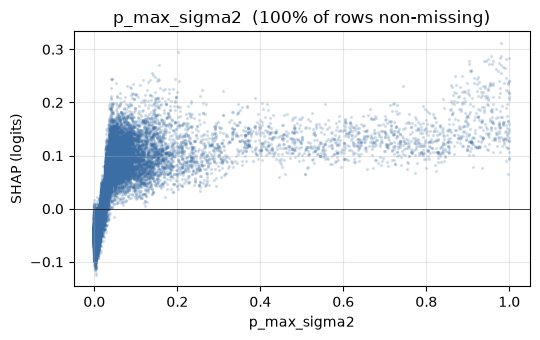

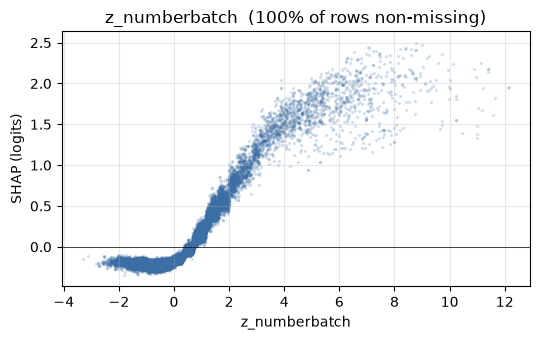

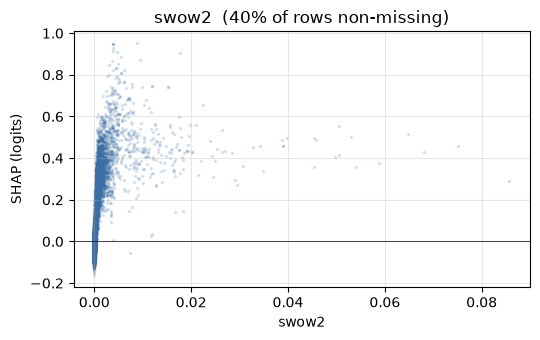

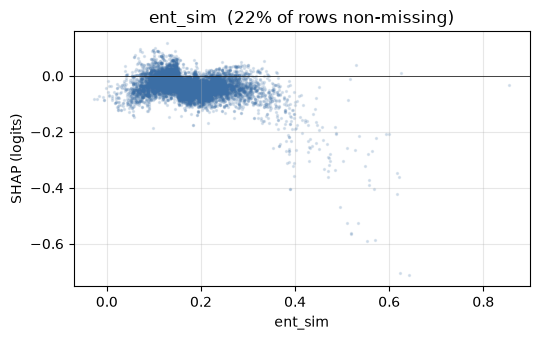

In [7]:
for feat in ["p_max_sigma2", "z_numberbatch", "swow2", "ent_sim"]:
    j = names.index(feat)
    fig, ax = plt.subplots(figsize=(5.5, 3.5))
    ok = np.isfinite(Xs[:, j])
    ax.scatter(Xs[ok, j], sv[ok, j], s=2, alpha=.15, color="#3b6ea5")
    ax.axhline(0, color="k", lw=.5)
    ax.set_xlabel(feat); ax.set_ylabel("SHAP (logits)")
    ax.set_title(f"{feat}  ({ok.mean():.0%} of rows non-missing)")
    ax.grid(alpha=.3); plt.tight_layout(); plt.show()

## Does the model lean on different features at step 1 vs later?

Step 1 is the decision the spymaster actually depends on; later steps were
measured as near-noise (`docs/log.md`). If the fitted model is spending
capacity differently there, it shows up here.

In [8]:
ev = np.repeat(np.arange(len(groups)), groups)[idx]
s1 = step[ev] == 0
a1, a2 = np.abs(sv[s1]).mean(axis=0), np.abs(sv[~s1]).mean(axis=0)
o = np.argsort(-(a1 + a2))[:15]
print(f"  {'feature':22s} {'step 1':>8s} {'step 2+':>8s} {'ratio':>7s}")
for i in o:
    print(f"  {names[i]:22s} {a1[i]:8.4f} {a2[i]:8.4f} {a1[i]/max(a2[i],1e-9):7.2f}")

  feature                  step 1  step 2+   ratio
  z_numberbatch            0.3048   0.2299    1.33
  k                        0.1611   0.1044    1.54
  rank_glove               0.1198   0.1233    0.97
  word_mean_sim            0.1165   0.1199    0.97
  word_sd_sim              0.1195   0.1141    1.05
  rank_numberbatch         0.1206   0.1125    1.07
  swow2_share              0.1171   0.1123    1.04
  p_max_sigma3             0.0960   0.0891    1.08
  z_glove                  0.0912   0.0915    1.00
  swow2                    0.0895   0.0794    1.13
  own_min_space            0.0634   0.0627    1.01
  cohesion_rank            0.0559   0.0619    0.90
  p_max_sigma2             0.0610   0.0515    1.18
  swow1                    0.0634   0.0394    1.61
  cohesion                 0.0499   0.0526    0.95
